In [1]:
import string
from random import random

import torch
from models import *

data = open('names.txt', 'r').read().splitlines(keepends=False)
print(data[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [2]:
bigram = Bigram()
bigram.fit(data)

In [3]:
bigram.make(5)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [4]:
bigram.loss(data)

2.4543561935424805

In [2]:
generator = torch.Generator().manual_seed(1234)
nn = NN(generator=generator)

nn.fit(data)

Loss=2.4627


In [3]:
generator = torch.Generator().manual_seed(1234)
nn.make(generator=generator)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [3]:
stoi = {s: i+1 for i, s in enumerate(string.ascii_lowercase)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [37]:
context_size = 3

def build_datasets(data):
    X, Y = [], []
    for word in data:
        context = [0] * context_size
        for char in word + '.':
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(data)

n1 = int(len(data) * 0.8)
n2 = int(len(data) * 0.9)

Xtrain, ytrain = build_datasets(data[:n1])
Xdev, ydev = build_datasets(data[n1:n2])
Xtest, ytest = build_datasets(data[n2:])

In [58]:
generator = torch.Generator().manual_seed(2147483647)

batch_size = 32
vocab_size = 27
embed_size = 10
W1_inputs = embed_size * context_size
n_hidden = 200
num_epochs = 200_000

C = torch.randn((vocab_size, embed_size), generator=generator)
W1 = torch.randn((W1_inputs, n_hidden), generator=generator) * (5/3) / (W1_inputs ** 0.5)
Wout = torch.tensor([1 / 27.0] * vocab_size * n_hidden).view((n_hidden, vocab_size))
bout = torch.randn(vocab_size, generator=generator) * 0

# batch norm params
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [p for p in [C, W1, bngain, bnbias, Wout, bout]]

for p in params:
    p.requires_grad = True

In [59]:
sum(p.nelement() for p in params)

12097

In [60]:
def learning_rate(epoch):
    return 0.5 if epoch < num_epochs / 2 else 0.001

In [61]:
stepi = []
lossi = []

In [62]:
for epoch in range(num_epochs):
    # encode data
    idx = torch.randint(len(Xtrain), size=(batch_size,))
    xenc = C[Xtrain[idx]]
    # go through layers
    hpreact = xenc.view(xenc.shape[0], -1) @ W1
    #batch normalization
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
    hnorm = bngain * (hpreact - bnmean) / bnstd + bnbias

    with torch.no_grad():
        bnmean_running = bnmean_running * 0.999 + bnmean * 0.001
        bnstd_running = bnstd_running * 0.999 + bnstd * 0.001

    #non linearity
    h = torch.tanh(hnorm)
    logits = h @ Wout + bout
    # softmax
    loss = F.cross_entropy(logits, ytrain[idx])

    # backward pass
    for p in params:
        p.grad = None

    loss.backward()
    # update
    for p in params:
        p.data += -learning_rate(epoch) * p.grad

    stepi.append(epoch)
    lossi.append(loss.item())

print(loss)

tensor(2.0246, grad_fn=<NllLossBackward0>)


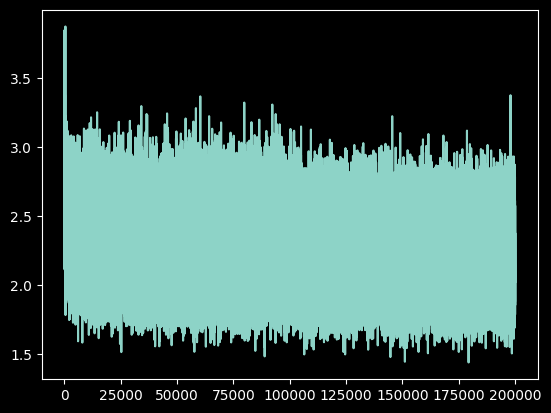

In [63]:
import matplotlib.pyplot as plt
plt.plot(stepi, lossi)

In [64]:
xenc = C[Xdev]
hpreact = xenc.view(-1, W1_inputs) @ W1
bnmean = hpreact.mean(0, keepdim=True)
bnstd = hpreact.std(0, keepdim=True)

hnorm = bngain * (hpreact - bnmean) / bnstd + bnbias

h = torch.tanh(hnorm)
logits = h @ Wout + bout
# softmax
loss = F.cross_entropy(logits, ydev)
loss.item()

2.223644733428955

In [65]:
generator = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    context = [0] * context_size
    out = []
    while True:
        xenc = C[torch.tensor(context)]
        hpreact = xenc.view(1, -1) @ W1

        hnorm = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias

        h = torch.tanh(hnorm)
        logits = h @ Wout + bout

        probs = F.softmax(logits, dim=1)

        idx = torch.multinomial(probs, num_samples=1, generator=generator).item()
        out.append(itos[idx])

        context = context[1:] + [idx]
        if idx == 0:
            break

    print(''.join(out))

cer.
maleah.
makio.
zity.
kell.
ima.
tainellayk.
katar.
samiyah.
javer.
gotai.
molie.
cavo.
kerteda.
kaley.
maside.
enkaviyn.
ryobs.
malline.
vtarlys.
